In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Thesis_Sihabul_Islam_Safin']


In [6]:
# ============================================================
#  CELL 1 — CLEAN GOOGLE DRIVE MOUNT
# ============================================================

import os
import shutil
import time

# ── REMOVE OLD MOUNT FOLDER IF EXISTS ───────────────────────

if os.path.exists('/content/drive'):

    try:

        shutil.rmtree('/content/drive')

        print("✅ Old /content/drive removed.")

    except Exception as e:

        print("⚠️ Could not remove old drive folder:")
        print(e)

print()

# ── REMOUNT GOOGLE DRIVE ────────────────────────────────────

from google.colab import drive

drive.mount('/content/drive')

print()
print("✅ Google Drive mounted successfully.")
print()

# ── WAIT FOR GOOGLE DRIVE SYNC ──────────────────────────────

time.sleep(5)

# ── DEBUG CHECK ─────────────────────────────────────────────

BASE_DIR = "/content/drive/MyDrive/Thesis_Sihabul_Islam_Safin"

print("BASE EXISTS:")
print(os.path.exists(BASE_DIR))
print()

print("INSIDE BASE:")
print(os.listdir(BASE_DIR))
print()

✅ Old /content/drive removed.

Mounted at /content/drive

✅ Google Drive mounted successfully.

BASE EXISTS:
True

INSIDE BASE:
['data', 'outputs', 'comparison', 'MODEL_A_Qwen_Complete', 'MODEL_B_Gemma_Complete.ipynb', 'MODEL_C_LLaMA_Complete.ipynb']



  STEP 08 — FINAL MODEL COMPARISON
  Bangla → Chittagonian Translation Thesis

  DEBUG CHECK

BASE EXISTS:
True

OUTPUT EXISTS:
True

OUTPUT CONTENTS:
['qwen', 'gemma', 'llama']

📁 Checking required files...

✅ Qwen2.5-3B
   /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/outputs/qwen/results_model_A_Qwen.json
✅ Gemma-2B-IT
   /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/outputs/gemma/results_model_B_Gemma.json
✅ LLaMA-3.2-3B
   /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/outputs/llama/results_model_C_LLaMA.json

✅ All required files found.

✅ Results loaded successfully.

          Model    BLEU   chrF++  ROUGE-1  ROUGE-2  ROUGE-L
0    Qwen2.5-3B  0.3518  11.9757      0.0      0.0      0.0
1   Gemma-2B-IT  1.3491  18.1971      0.0      0.0      0.0
2  LLaMA-3.2-3B  0.3755  16.8909      0.0      0.0      0.0

✅ CSV saved: /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/comparison/final_model_comparison.csv

  🏆 BEST MODEL ANALYSIS

Best Overall Model : Gemma-2B-IT
Averag

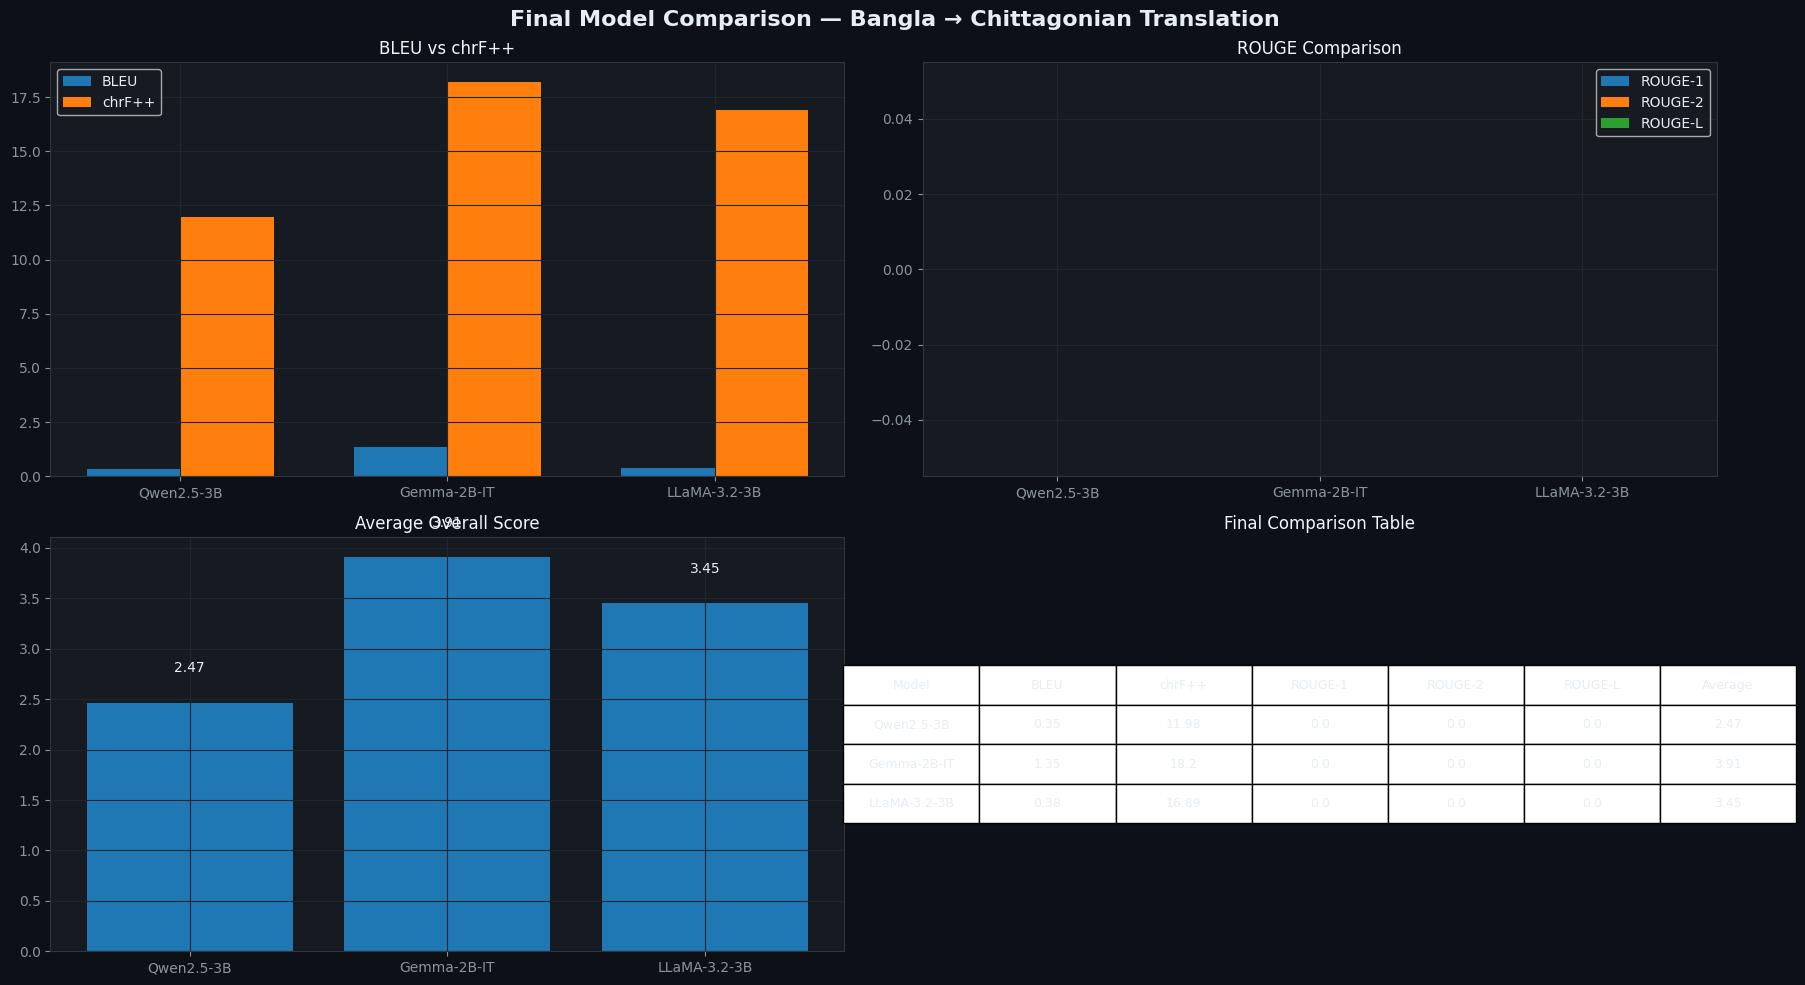

✅ Chart saved: /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/comparison/final_comparison_summary.png

✅ JSON report saved: /content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/comparison/final_comparison_report.json

  📋 FINAL MODEL RANKING

1. Gemma-2B-IT → Average Score: 3.91
2. LLaMA-3.2-3B → Average Score: 3.45
3. Qwen2.5-3B → Average Score: 2.47

🏆 BEST MODEL: Gemma-2B-IT

🎓 Thesis comparison complete.

📂 Saved inside:
/content/drive/MyDrive/Thesis_Sihabul_Islam_Safin/comparison


In [7]:
# ============================================================
#  STEP 08 — FINAL MODEL COMPARISON
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("=" * 62)
print("  STEP 08 — FINAL MODEL COMPARISON")
print("  Bangla → Chittagonian Translation Thesis")
print("=" * 62)
print()


# ── DARK THEME ───────────────────────────────────────────────

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['axes.titlecolor'] = '#f0f6fc'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['font.family'] = 'DejaVu Sans'


# ── BASE DIRECTORY ──────────────────────────────────────────

BASE_DIR = "/content/drive/MyDrive/Thesis_Sihabul_Islam_Safin"

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

COMPARISON_DIR = os.path.join(
    BASE_DIR,
    "comparison"
)

os.makedirs(COMPARISON_DIR, exist_ok=True)


# ── DEBUG CHECK ─────────────────────────────────────────────

print("=" * 62)
print("  DEBUG CHECK")
print("=" * 62)
print()

print("BASE EXISTS:")
print(os.path.exists(BASE_DIR))
print()

print("OUTPUT EXISTS:")
print(os.path.exists(OUTPUT_DIR))
print()

print("OUTPUT CONTENTS:")
print(os.listdir(OUTPUT_DIR))
print()


# ── FILE PATHS ──────────────────────────────────────────────

FILES = {

    "Qwen2.5-3B": os.path.join(
        OUTPUT_DIR,
        "qwen",
        "results_model_A_Qwen.json"
    ),

    "Gemma-2B-IT": os.path.join(
        OUTPUT_DIR,
        "gemma",
        "results_model_B_Gemma.json"
    ),

    "LLaMA-3.2-3B": os.path.join(
        OUTPUT_DIR,
        "llama",
        "results_model_C_LLaMA.json"
    ),
}


print("📁 Checking required files...")
print()

missing = []

for model_name, file_name in FILES.items():

    if os.path.exists(file_name):

        print(f"✅ {model_name}")
        print(f"   {file_name}")

    else:

        print(f"❌ Missing: {file_name}")

        missing.append(file_name)

print()

if len(missing) > 0:

    raise FileNotFoundError(
        f"Missing files: {missing}\n"
        "Run all Model notebooks first."
    )

print("✅ All required files found.")
print()


# ── LOAD RESULTS ─────────────────────────────────────────────

results = []

for model_name, file_name in FILES.items():

    with open(file_name, 'r', encoding='utf-8') as f:

        data = json.load(f)

    scores = data.get("scores", {})

    results.append({

        "Model": model_name,

        "BLEU": scores.get("BLEU", 0),

        "chrF++": scores.get("chrF++", 0),

        "ROUGE-1": scores.get("ROUGE-1", 0),

        "ROUGE-2": scores.get("ROUGE-2", 0),

        "ROUGE-L": scores.get("ROUGE-L", 0),
    })

print("✅ Results loaded successfully.")
print()

df = pd.DataFrame(results)

print(df)
print()


# ── SAVE CSV ─────────────────────────────────────────────────

csv_file = os.path.join(
    COMPARISON_DIR,
    "final_model_comparison.csv"
)

df.to_csv(
    csv_file,
    index=False,
    encoding='utf-8'
)

print(f"✅ CSV saved: {csv_file}")
print()


# ── AVERAGE SCORE ───────────────────────────────────────────

metric_cols = [
    "BLEU",
    "chrF++",
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L"
]

df["Average"] = df[metric_cols].mean(axis=1)

best_idx = df["Average"].idxmax()

best_model = df.loc[best_idx, "Model"]

best_score = df.loc[best_idx, "Average"]

print("=" * 62)
print("  🏆 BEST MODEL ANALYSIS")
print("=" * 62)
print()

print(f"Best Overall Model : {best_model}")
print(f"Average Score      : {best_score:.2f}")
print()


# ── VISUALIZATION ───────────────────────────────────────────

fig = plt.figure(figsize=(18, 10))

ax1 = fig.add_subplot(221)

x = np.arange(len(df["Model"]))

w = 0.35

ax1.bar(x - w/2, df["BLEU"], width=w, label='BLEU')

ax1.bar(x + w/2, df["chrF++"], width=w, label='chrF++')

ax1.set_xticks(x)

ax1.set_xticklabels(df["Model"])

ax1.set_title("BLEU vs chrF++")

ax1.legend()


ax2 = fig.add_subplot(222)

w2 = 0.25

ax2.bar(x - w2, df["ROUGE-1"], width=w2, label='ROUGE-1')

ax2.bar(x, df["ROUGE-2"], width=w2, label='ROUGE-2')

ax2.bar(x + w2, df["ROUGE-L"], width=w2, label='ROUGE-L')

ax2.set_xticks(x)

ax2.set_xticklabels(df["Model"])

ax2.set_title("ROUGE Comparison")

ax2.legend()


ax3 = fig.add_subplot(223)

bars = ax3.bar(df["Model"], df["Average"])

for b in bars:

    ax3.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.3,
        f"{b.get_height():.2f}",
        ha='center'
    )

ax3.set_title("Average Overall Score")


ax4 = fig.add_subplot(224)

ax4.axis('off')

table = ax4.table(

    cellText=df.round(2).values,

    colLabels=df.columns,

    loc='center',

    cellLoc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(1.2, 2)

ax4.set_title("Final Comparison Table")


fig.suptitle(

    "Final Model Comparison — Bangla → Chittagonian Translation",

    fontsize=16,

    fontweight='bold'
)

plt.tight_layout()

chart_file = os.path.join(
    COMPARISON_DIR,
    "final_comparison_summary.png"
)

plt.savefig(
    chart_file,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print(f"✅ Chart saved: {chart_file}")
print()


# ── SAVE FINAL REPORT ───────────────────────────────────────

report = {

    "best_model": best_model,

    "best_average_score": round(float(best_score), 4),

    "models": results,
}

report_file = os.path.join(
    COMPARISON_DIR,
    "final_comparison_report.json"
)

with open(
    report_file,
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        report,
        f,
        indent=2,
        ensure_ascii=False
    )

print(f"✅ JSON report saved: {report_file}")
print()


# ── FINAL RANKING ───────────────────────────────────────────

print("=" * 62)
print("  📋 FINAL MODEL RANKING")
print("=" * 62)
print()

ranked_df = df.sort_values(
    by="Average",
    ascending=False
).reset_index(drop=True)

for i, row in ranked_df.iterrows():

    print(
        f"{i+1}. {row['Model']} "
        f"→ Average Score: {row['Average']:.2f}"
    )

print()

print(f"🏆 BEST MODEL: {best_model}")

print()
print("🎓 Thesis comparison complete.")
print()

print("📂 Saved inside:")
print(COMPARISON_DIR)